Detected 7 distinct paper fragments.


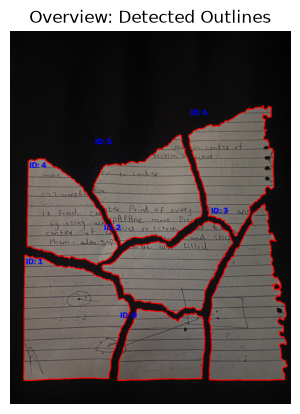

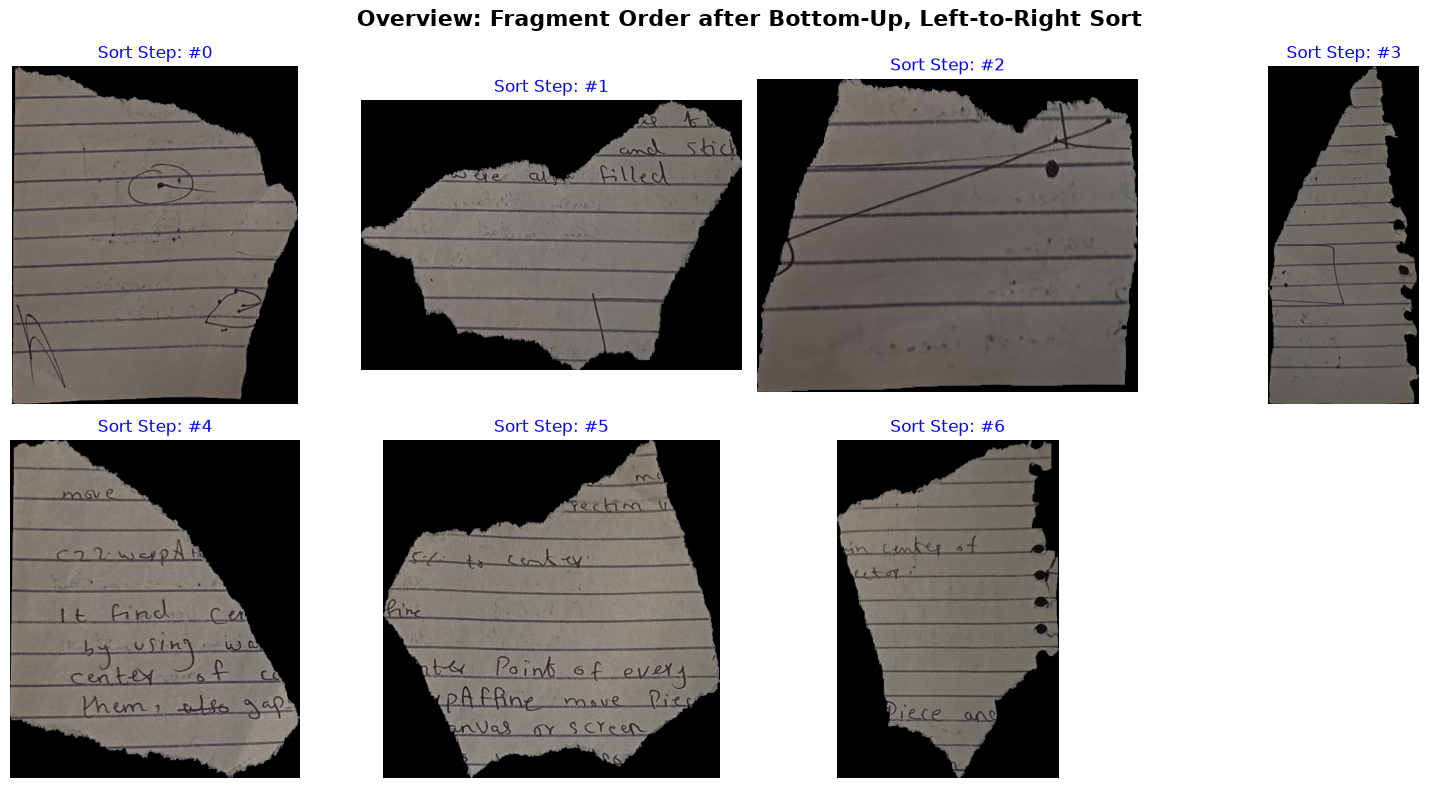

Detected flat edges: side1=left, side2=None


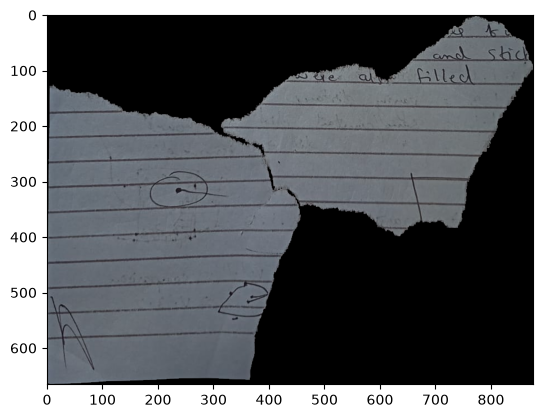

Detected flat edges: side1=None, side2=None


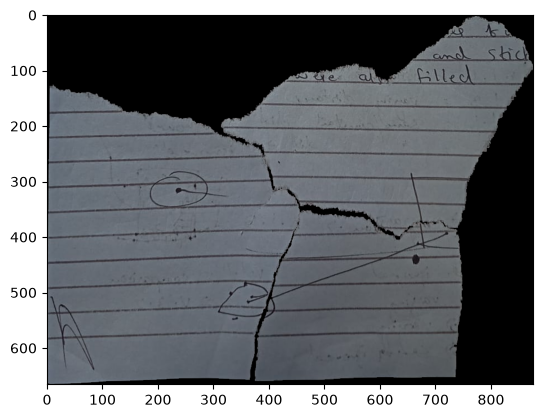

Detected flat edges: side1=None, side2=bottom


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

isolated_pieces_list = []


def display_detected_fragments(image_path):
    global isolated_pieces_list
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    min_area = (h * w) * 0.009
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]

    print(f"Detected {len(fragments)} distinct paper fragments.")

    highlighted_img = img_rgb.copy()
    num_fragments = len(fragments)
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols

    plt.figure(figsize=(15, rows * 4))

    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4)
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(
            highlighted_img,
            f"ID: {idx}",
            (x + 10, y + 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3,
        )

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")

    temporary_storage = []
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y : y + ph, x : x + pw]

        temporary_storage.append(
            {"img": cropped_piece, "orig_x": x, "orig_y": y, "h": ph, "w": pw}
        )

    plt.tight_layout()
    plt.show()

    return temporary_storage, w


def sort_pieces_bottom_up_grid_wise(fragment_data, row_threshold_ratio=0.15):
    if not fragment_data:
        return []

    all_heights = [entry["h"] for entry in fragment_data]
    avg_height = np.mean(all_heights) if all_heights else 100
    row_threshold = avg_height * row_threshold_ratio * 5

    rows_list = []

    for entry in fragment_data:
        center_y = entry["orig_y"] + (entry["h"] / 2)
        placed = False

        for row in rows_list:
            row_center_y = np.mean([e["orig_y"] + (e["h"] / 2) for e in row])
            if abs(center_y - row_center_y) < row_threshold:
                row.append(entry)
                placed = True
                break

        if not placed:
            rows_list.append([entry])

    # Sort rows from bottom to top
    rows_list.sort(
        key=lambda r: np.mean([e["orig_y"] + (e["h"] / 2) for e in r]),
        reverse=True,
    )

    sorted_pieces = []
    for row in rows_list:
        # Sort left to right within each row
        row.sort(key=lambda e: e["orig_x"])
        for entry in row:
            sorted_pieces.append(entry["img"])

    return sorted_pieces


def get_thresh(img):
    return cv2.threshold(
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY
    )[1]


def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y : -min_y + hA, -min_x : -min_x + wA][threshA > 0] = imgA[
        threshA > 0
    ]
    canvas[dy - min_y : dy - min_y + hB, dx - min_x : dx - min_x + wB][
        threshB > 0
    ] = imgB[threshB > 0]
    return canvas


def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (
        (int(p2[0].max()) - int(p3[0].max()))
        if ref == "bottom"
        else (int(p2[0].min()) - int(p3[0].min()))
    )

    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {
        r: np.max(x2[y2 == r])
        for r in range(np.min(p2[0]), np.max(p2[0]) + 1)
        if len(x2[y2 == r]) > 0
    }
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {
        r: np.min(x3[y3 == r])
        for r in range(np.min(p3[0]), np.max(p3[0]) + 1)
        if len(x3[y3 == r]) > 0
    }

    dx = int(
        np.percentile([b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90)
    )
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)


def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)

    dx = (np.min(x0) if side == "left" else np.max(x0)) - (
        np.min(x1) if side == "left" else np.max(x1)
    )
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}

    dy = int(
        np.percentile([bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92)
    )
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)


def ad_stitch(img_base, img_patch):
    m_b = ((cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(
        np.uint8
    )
    m_p = ((cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(
        np.uint8
    )

    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out, dist_in = cv2.distanceTransform(
        ~m_b, cv2.DIST_L2, 5
    ), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)

    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float("inf")

    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue

            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]

            touching = (
                np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            )
            deep = (
                np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            )
            score = -touching + (4.0 * deep)

            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros(
        (
            max(h_b + oy, h_p + best_dy + oy),
            max(w_b + ox, w_p + best_dx + ox),
            3,
        ),
        dtype=np.uint8,
    )
    canvas[oy : oy + h_b, ox : ox + w_b] = img_base
    canvas[best_dy + oy : best_dy + oy + h_p, best_dx + ox : best_dx + ox + w_p][
        m_p == 255
    ] = img_patch[m_p == 255]
    return canvas


def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue

        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1

        cropped_thresh = thresh[ymin : ymax + 1, xmin : xmax + 1]
        ch, cw = cropped_thresh.shape
        mw, mh = max(1, int(cw * 0.1)), max(1, int(ch * 0.1))

        flatness = {}

        top_profile = np.argmax(cropped_thresh == 255, axis=0)
        top_profile_trimmed = top_profile[mw:-mw]
        if len(top_profile_trimmed) > 0:
            flatness["top"] = np.std(top_profile_trimmed)

        bottom_profile = ch - 1 - np.argmax(cropped_thresh[::-1, :] == 255, axis=0)
        bottom_profile_trimmed = bottom_profile[mw:-mw]
        if len(bottom_profile_trimmed) > 0:
            flatness["bottom"] = np.std(bottom_profile_trimmed)

        left_profile = np.argmax(cropped_thresh == 255, axis=1)
        left_profile_trimmed = left_profile[mh:-mh]
        if len(left_profile_trimmed) > 0:
            flatness["left"] = np.std(left_profile_trimmed)

        right_profile = cw - 1 - np.argmax(cropped_thresh[:, ::-1] == 255, axis=1)
        right_profile_trimmed = right_profile[mh:-mh]
        if len(right_profile_trimmed) > 0:
            flatness["right"] = np.std(right_profile_trimmed)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda item: item[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)

    return sides[0], sides[1]


def display_final_canvas(raw_fragment_metadata, image_width):
    if raw_fragment_metadata:
        positions = sort_pieces_bottom_up_grid_wise(raw_fragment_metadata)
        if not positions:
            return
        p=positions
        p = positions
        # Only apply manual sorting if exactly 18 pieces are detected
        # if len(p) == 18:
        #     positions = [
        #         p[0], p[3], p[1], p[2], p[5], p[4], p[6], p[7], p[9], 
        #         p[10], p[8], p[12], p[11], p[15], p[13], p[14], p[16], p[17]
        #     ]
        # else:
        #     print(f"Warning: Expected 18 elements for manual sort, but got {len(p)}. Using default automated order.")        
        num_sorted = len(positions)
        view_cols = 4
        view_rows = (num_sorted + (view_cols - 1)) // view_cols
        plt.figure(figsize=(16, view_rows * 4))

        for idx, piece_img in enumerate(positions):
            plt.subplot(view_rows, view_cols, idx + 1)
            plt.imshow(piece_img)
            plt.title(f"Sort Step: #{idx}", fontsize=12, color="blue")
            plt.axis("off")

        plt.suptitle(
            "Overview: Fragment Order after Bottom-Up, Left-to-Right Sort",
            fontsize=16,
            weight="bold",
        )
        plt.tight_layout()
        plt.show()
        # ---------------------------------------------------------------

        can = positions[0]

        for i in range(1, len(positions)):
            next_piece = positions[i]
            side1, side2 = detect_flat_edges(can, next_piece)
            print(f"Detected flat edges: side1={side1}, side2={side2}")

            if side1 == side2 and side1 is not None:
                if side1 in ["bottom", "top"]:
                    can = stitch_by_edge(can, next_piece, ref=side1)
                elif side1 in ["left", "right"]:
                    can = stitch_by_margin(can, next_piece, side=side1)
            else:
                can = ad_stitch(can, next_piece)

            plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
            plt.show()

        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
        plt.title("Final Reconstruction Canvas")
        plt.axis("off")
        plt.show()


raw_fragment_metadata, image_width = display_detected_fragments(
    r"D:\PythonProject1\Intern\Images\img158.jpeg"
)
display_final_canvas(raw_fragment_metadata, image_width)